<a href="https://colab.research.google.com/github/sanvi-g07/insurance-cross-sell-prediction/blob/main/insurance_cross_sell_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, f1_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import NeighbourhoodCleaningRule

#Get data

In [ ]:
path = kagglehub.dataset_download("anmolkumar/health-insurance-cross-sell-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'health-insurance-cross-sell-prediction' dataset.
Path to dataset files: /kaggle/input/health-insurance-cross-sell-prediction


In [ ]:
df = pd.read_csv(f"{path}/train.csv")
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0


# EDA

In [ ]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
Driving_License,0
Region_Code,0
Previously_Insured,0
Vehicle_Age,0
Vehicle_Damage,0
Annual_Premium,0
Policy_Sales_Channel,0


In [ ]:
df['Response'].value_counts()

,count
Response,
0,334399
1,46710


In [ ]:
df['Response'].value_counts(normalize=True)

,proportion
Response,
0,0.877437
1,0.122563


In [ ]:
df.dtypes

,0
id,int64
Gender,object
Age,int64
Driving_License,int64
Region_Code,float64
Previously_Insured,int64
Vehicle_Age,object
Vehicle_Damage,object
Annual_Premium,float64
Policy_Sales_Channel,float64


In [ ]:
num_cols = ['Age', 'Annual_Premium', 'Vintage']
cat_cols = ['Gender', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Policy_Sales_Channel']

## Numeric Columns

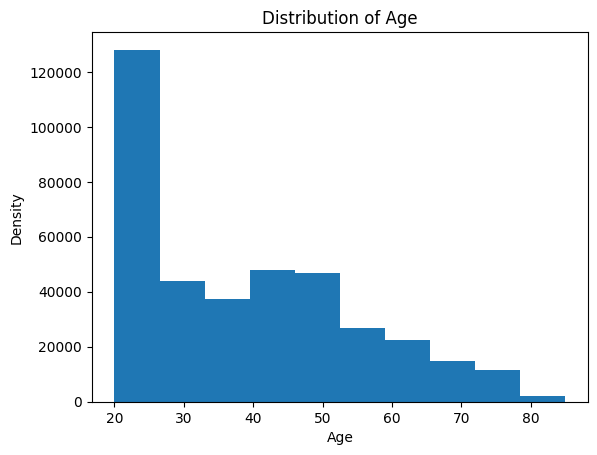

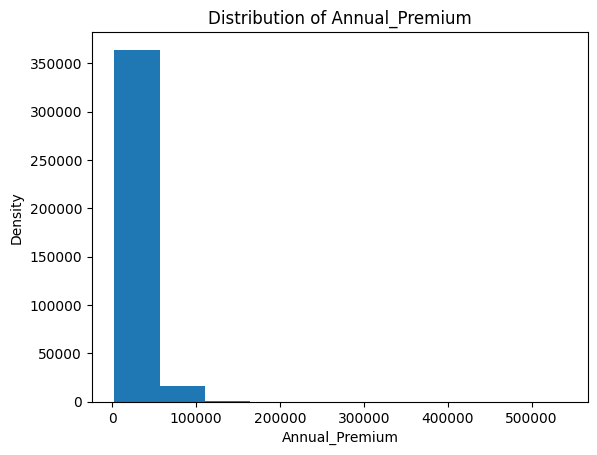

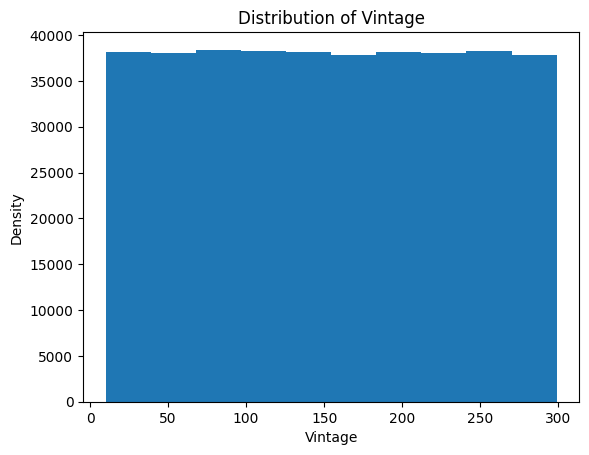

In [ ]:
for col in num_cols:
    plt.figure()
    plt.hist(df[col])
    x_name = col
    plt.xlabel(x_name)
    y_name = 'Density'
    plt.ylabel(y_name)
    plt.title('Distribution of {x_name}'.format(x_name=x_name))

In [ ]:
for col in num_cols:
  print(df[col].describe())
  print()

count    381109.000000
mean         38.822584
std          15.511611
min          20.000000
25%          25.000000
50%          36.000000
75%          49.000000
max          85.000000
Name: Age, dtype: float64

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

count    381109.000000
mean        154.347397
std          83.671304
min          10.000000
25%          82.000000
50%         154.000000
75%         227.000000
max         299.000000
Name: Vintage, dtype: float64



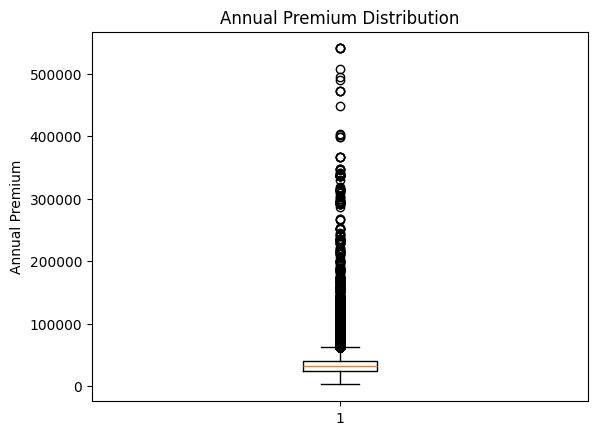

In [ ]:
plt.boxplot(df['Annual_Premium'])
plt.title('Annual Premium Distribution')
plt.ylabel('Annual Premium')
plt.show()

In [ ]:
corr_plot = df[num_cols].corr()
corr_plot.style.background_gradient(cmap='coolwarm')

,Age,Annual_Premium,Vintage
Age,1.000000,0.067507,-0.001264
Annual_Premium,0.067507,1.000000,-0.000608
Vintage,-0.001264,-0.000608,1.000000


In [ ]:
for col in ['Age', 'Annual_Premium', 'Vintage']:
    df[f'{col}_bin'] = pd.qcut(df[col], q=10, duplicates='drop')
    print(df.groupby(f'{col}_bin')['Response'].mean())
    print()

Age_bin
(19.999, 22.0]    0.034545
(22.0, 24.0]      0.035945
(24.0, 25.0]      0.035569
(25.0, 29.0]      0.057177
(29.0, 36.0]      0.191493
(36.0, 42.0]      0.213614
(42.0, 47.0]      0.216505
(47.0, 53.0]      0.194097
(53.0, 62.0]      0.156613
(62.0, 85.0]      0.090857
Name: Response, dtype: float64

Annual_Premium_bin
(2629.999, 21583.6]    0.123993
(21583.6, 26238.0]     0.096537
(26238.0, 29082.0]     0.101637
(29082.0, 31669.0]     0.110231
(31669.0, 34406.0]     0.113981
(34406.0, 37548.0]     0.124216
(37548.0, 41711.0]     0.135254
(41711.0, 48431.0]     0.143948
(48431.0, 540165.0]    0.151854
Name: Response, dtype: float64

Vintage_bin
(9.999, 38.0]     0.124410
(38.0, 68.0]      0.123932
(68.0, 96.0]      0.119500
(96.0, 125.0]     0.121268
(125.0, 154.0]    0.125082
(154.0, 183.0]    0.120909
(183.0, 212.0]    0.125452
(212.0, 241.0]    0.122768
(241.0, 270.0]    0.119981
(270.0, 299.0]    0.122196
Name: Response, dtype: float64



/tmp/ipykernel_65746/3782923991.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(f'{col}_bin')['Response'].mean())
/tmp/ipykernel_65746/3782923991.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(f'{col}_bin')['Response'].mean())
/tmp/ipykernel_65746/3782923991.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(f'{col}_bin')['Response'].mean())


## Categorical Columns

In [ ]:
for col in cat_cols:
  print(df[col].value_counts())
  print()

Gender
Male      206089
Female    175020
Name: count, dtype: int64

Driving_License
1    380297
0       812
Name: count, dtype: int64

Region_Code
28.0    106415
8.0      33877
46.0     19749
41.0     18263
15.0     13308
30.0     12191
29.0     11065
50.0     10243
3.0       9251
11.0      9232
36.0      8797
33.0      7654
47.0      7436
35.0      6942
6.0       6280
45.0      5605
37.0      5501
18.0      5153
48.0      4681
14.0      4678
39.0      4644
10.0      4374
21.0      4266
2.0       4038
13.0      4036
7.0       3279
12.0      3198
9.0       3101
27.0      2823
32.0      2787
43.0      2639
17.0      2617
26.0      2587
25.0      2503
24.0      2415
38.0      2026
0.0       2021
16.0      2007
23.0      1960
31.0      1960
20.0      1935
49.0      1832
4.0       1801
34.0      1664
19.0      1535
22.0      1309
40.0      1295
5.0       1279
1.0       1008
44.0       808
42.0       591
52.0       267
51.0       183
Name: count, dtype: int64

Previously_Insured
0    206481


In [ ]:
for col in cat_cols:
    print(df.groupby(col)['Response'].mean().sort_values(ascending=False))
    print()

Gender
Male      0.138411
Female    0.103902
Name: Response, dtype: float64

Driving_License
1    0.122717
0    0.050493
Name: Response, dtype: float64

Region_Code
38.0    0.192004
28.0    0.187163
19.0    0.162866
4.0     0.158245
23.0    0.153061
51.0    0.153005
24.0    0.141615
7.0     0.131747
18.0    0.131574
3.0     0.127662
35.0    0.124604
39.0    0.123600
52.0    0.123596
29.0    0.123362
41.0    0.121776
40.0    0.118147
5.0     0.115715
20.0    0.115245
11.0    0.112760
45.0    0.109723
1.0     0.108135
46.0    0.102891
48.0    0.101901
31.0    0.100510
33.0    0.099294
12.0    0.097561
8.0     0.096142
43.0    0.092459
14.0    0.090209
13.0    0.090188
47.0    0.087682
0.0     0.086096
32.0    0.085755
9.0     0.081587
36.0    0.079914
37.0    0.079258
34.0    0.075721
49.0    0.074782
42.0    0.074450
27.0    0.074035
30.0    0.073825
26.0    0.072284
15.0    0.071987
2.0     0.071075
21.0    0.071027
17.0    0.070310
6.0     0.069904
16.0    0.066766
22.0    0.063407
50

In [ ]:
df.groupby('Policy_Sales_Channel')['Response'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Policy_Sales_Channel,,
43.0,1.000000,1
123.0,1.000000,1
28.0,0.333333,3
27.0,0.333333,3
36.0,0.326923,52
...,...,...
134.0,0.000000,10
144.0,0.000000,1
143.0,0.000000,1


In [ ]:
df.groupby('Region_Code')['Response'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
Region_Code,,
38.0,0.192004,2026
28.0,0.187163,106415
19.0,0.162866,1535
4.0,0.158245,1801
23.0,0.153061,1960
51.0,0.153005,183
24.0,0.141615,2415
7.0,0.131747,3279
18.0,0.131574,5153


# Feature Engineering (Before Split)

In [ ]:
df['Annual_Premium_log'] = np.log1p(df['Annual_Premium'])

Text(0.5, 1.0, 'Distribution of Annual_Premium_log')

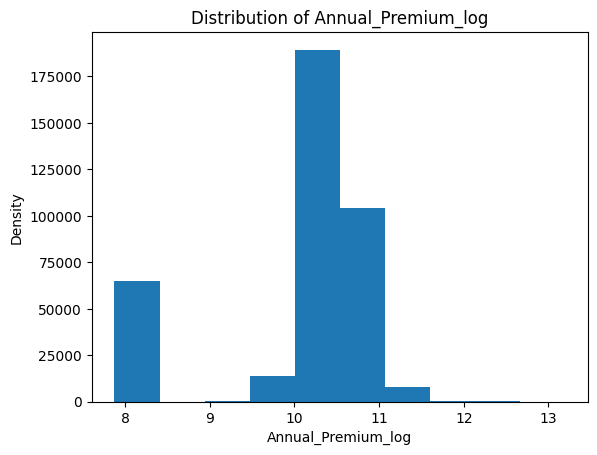

In [ ]:
plt.figure()
plt.hist(df["Annual_Premium_log"])
x_name = "Annual_Premium_log"
plt.xlabel(x_name)
y_name = 'Density'
plt.ylabel(y_name)
plt.title('Distribution of {x_name}'.format(x_name=x_name))

In [ ]:
df['Premium_per_Vintage'] = np.where(df['Vintage'] != 0, df['Annual_Premium'] / df['Vintage'], 0)
df['Damaged_and_Uninsured'] = ((df['Vehicle_Damage'] == 'Yes') & (df['Previously_Insured'] == 0)).astype(int)

In [ ]:
df

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Annual_Premium_log,Premium_per_Vintage,Damaged_and_Uninsured
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1,10.607946,186.423963,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0,10.420405,183.256831,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1,10.553075,1418.296296,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0,10.261861,140.980296,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0,10.221832,705.025641,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381104,381105,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0,10.314636,342.840909,0
381105,381106,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0,10.597060,305.465649,0
381106,381107,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0,10.466498,218.124224,0
381107,381108,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0,10.705893,602.932432,1


In [ ]:
del df['id']
del df['Age_bin']
del df['Annual_Premium_bin']
del df['Vintage_bin']

KeyError: 'Age_bin'

In [ ]:
df

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Annual_Premium_log,Premium_per_Vintage,Damaged_and_Uninsured
0,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1,10.607946,186.423963,1
1,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0,10.420405,183.256831,0
2,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1,10.553075,1418.296296,1
3,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0,10.261861,140.980296,0
4,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0,10.221832,705.025641,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
381104,Male,74,1,26.0,1,1-2 Year,No,30170.0,26.0,88,0,10.314636,342.840909,0
381105,Male,30,1,37.0,1,< 1 Year,No,40016.0,152.0,131,0,10.597060,305.465649,0
381106,Male,21,1,30.0,1,< 1 Year,No,35118.0,160.0,161,0,10.466498,218.124224,0
381107,Female,68,1,14.0,0,> 2 Years,Yes,44617.0,124.0,74,0,10.705893,602.932432,1


In [ ]:
df.columns

Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response', 'Annual_Premium_log',
       'Premium_per_Vintage', 'Damaged_and_Uninsured'],
      dtype='object')

#Encoding

In [ ]:
age_order = ['< 1 Year', '1-2 Year', '> 2 Years']
encoder = OrdinalEncoder(categories=[age_order])
df['Vehicle_Age'] = encoder.fit_transform(df[['Vehicle_Age']])

df['Vehicle_Damage'] = (df['Vehicle_Damage'] == 'Yes').astype(int)
df['Gender'] = (df['Gender'] == 'Female').astype(int)

# Train/Validation/Test Split

In [ ]:
num_cols = ['Age', 'Annual_Premium', 'Vintage', 'Annual_Premium_log', 'Premium_per_Vintage']
cat_cols = ['Gender', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage',
       'Policy_Sales_Channel', 'Damaged_and_Uninsured']
target_col = 'Response'

X = df[num_cols + cat_cols].copy()
y = df[target_col].copy()

X_full_train, X_test, y_full_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=2)
X_train, X_val, y_train, y_val = train_test_split(X_full_train, y_full_train, test_size=(15/85), stratify=y_full_train, random_state=2)

In [ ]:
len(X_full_train), len(X_train), len(X_val), len(X_test)

(323942, 266775, 57167, 57167)

#Feature Engineering (After Split)

In [ ]:
X_train

,Age,Annual_Premium,Vintage,Annual_Premium_log,Premium_per_Vintage,Gender,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Policy_Sales_Channel,Damaged_and_Uninsured
124908,49,34229.0,233,10.440858,146.905579,0,1,3.0,0,1.0,1,26.0,1
49161,45,24330.0,222,10.099507,109.594595,0,1,28.0,0,1.0,1,26.0,1
325237,23,30261.0,154,10.317648,196.500000,1,1,45.0,1,0.0,0,26.0,0
118984,23,30028.0,193,10.309919,155.585492,1,1,45.0,1,0.0,0,152.0,0
194511,24,28937.0,23,10.272911,1258.130435,0,1,24.0,0,0.0,1,152.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
367615,25,19082.0,235,9.856553,81.200000,1,1,23.0,1,0.0,0,152.0,0
270898,51,30528.0,226,10.326432,135.079646,0,1,28.0,0,1.0,1,124.0,1
343589,28,50352.0,105,10.826813,479.542857,0,1,21.0,0,0.0,1,152.0,1
291310,26,30858.0,150,10.337184,205.720000,1,1,45.0,1,0.0,0,152.0,0


In [ ]:
def smoothed_target_encode(train_col, train_target, smoothing=20):
    global_rate = train_target.mean()
    stats = train_target.groupby(train_col).agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + smoothing * global_rate) / (stats['count'] + smoothing)
    return smoothed, global_rate

In [ ]:
region_response_rates, global_rate = smoothed_target_encode(X_train['Region_Code'], y_train, smoothing=20)
channel_response_rates, global_rate = smoothed_target_encode(X_train['Policy_Sales_Channel'], y_train, smoothing=20)
global_rate = y_train.mean()

X_train["Region_Response_Rate"] = X_train["Region_Code"].map(region_response_rates)
X_train["Channel_Response_Rate"] = X_train["Policy_Sales_Channel"].map(channel_response_rates)

X_val["Region_Response_Rate"] = X_val["Region_Code"].map(region_response_rates)
X_val["Channel_Response_Rate"] = X_val["Policy_Sales_Channel"].map(channel_response_rates)

X_test["Region_Response_Rate"] = X_test["Region_Code"].map(region_response_rates)
X_test["Channel_Response_Rate"] = X_test["Policy_Sales_Channel"].map(channel_response_rates)

X_val['Region_Response_Rate'] = X_val['Region_Response_Rate'].fillna(global_rate)
X_val['Channel_Response_Rate'] = X_val['Channel_Response_Rate'].fillna(global_rate)
X_test['Region_Response_Rate'] = X_test['Region_Response_Rate'].fillna(global_rate)
X_test['Channel_Response_Rate'] = X_test['Channel_Response_Rate'].fillna(global_rate)

In [ ]:
del X_train['Annual_Premium']
del X_train['Region_Code']
del X_train['Policy_Sales_Channel']

del X_val['Annual_Premium']
del X_val['Region_Code']
del X_val['Policy_Sales_Channel']

del X_test['Annual_Premium']
del X_test['Region_Code']
del X_test['Policy_Sales_Channel']

In [ ]:
X_train

,Age,Vintage,Annual_Premium_log,Premium_per_Vintage,Gender,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage,Damaged_and_Uninsured,Region_Response_Rate,Channel_Response_Rate
124908,49,233,10.440858,146.905579,0,1,0,1.0,1,1,0.124665,0.198836
49161,45,222,10.099507,109.594595,0,1,0,1.0,1,1,0.187277,0.198836
325237,23,154,10.317648,196.500000,1,1,1,0.0,0,0,0.111816,0.198836
118984,23,193,10.309919,155.585492,1,1,1,0.0,0,0,0.111816,0.028796
194511,24,23,10.272911,1258.130435,0,1,0,0.0,1,1,0.139846,0.028796
...,...,...,...,...,...,...,...,...,...,...,...,...
367615,25,235,9.856553,81.200000,1,1,1,0.0,0,0,0.168819,0.028796
270898,51,226,10.326432,135.079646,0,1,0,1.0,1,1,0.187277,0.188880
343589,28,105,10.826813,479.542857,0,1,0,0.0,1,1,0.072756,0.028796
291310,26,150,10.337184,205.720000,1,1,1,0.0,0,0,0.111816,0.028796


#Scale features

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

#Class Imbalance Treatments

##SMOTE (Oversample)

In [ ]:
cat_cols = ['Gender', 'Driving_License', 'Vehicle_Age', 'Vehicle_Damage', 'Damaged_and_Uninsured']
cat_indices = [X_train.columns.get_loc(c) for c in cat_cols]

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=2)

X_train_smote, y_train_smote = smote_nc.fit_resample(X_train_sc, y_train)

comparison = pd.DataFrame({
    'before': y_train.value_counts().sort_index(),
    'after': pd.Series(y_train_smote).value_counts().sort_index()
})
print(comparison)
print(f"Original: {X_train_sc.shape[0]} rows")
print(f"After SMOTE: {X_train_smote.shape[0]} rows")

          before   after
Response                
0         234079  234079
1          32696  234079
Original: 266775 rows
After SMOTE: 468158 rows


## Neighbourhood Cleaning Rule (undersample)


In [ ]:
ncl = NeighbourhoodCleaningRule(n_jobs=-1)
X_train_ncl, y_train_ncl = ncl.fit_resample(X_train_sc, y_train)

comparison = pd.DataFrame({
    'before': y_train.value_counts().sort_index(),
    'after': pd.Series(y_train_ncl).value_counts().sort_index()
})
print(comparison)
print(f"Original: {X_train_sc.shape[0]} rows")
print(f"After NCL: {X_train_ncl.shape[0]} rows")

          before   after
Response                
0         234079  189603
1          32696   32696
Original: 266775 rows
After NCL: 222299 rows


#Train models

In [ ]:
def train_and_evaluate_model(model, X_train, y_train, X_eval, y_eval):
    # Fit
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    # Metrics
    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred)
    rec = recall_score(y_eval, y_pred)
    f1 = f1_score(y_eval, y_pred)
    roc_auc = roc_auc_score(y_eval, y_proba)
    pr_auc = average_precision_score(y_eval, y_proba)

    print(f"--- Metrics ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_eval, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Response', 'Response'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix')
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_eval, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve')
    plt.legend()
    plt.show()

    # Precision-Recall curve
    precisions, recalls, _ = precision_recall_curve(y_eval, y_proba)
    plt.figure()
    plt.plot(recalls, precisions, label=f'PR-AUC = {pr_auc:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve')
    plt.legend()
    plt.show()

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'roc_auc': roc_auc, 'pr_auc': pr_auc
    }

In [ ]:
scores = {}

##Logistic Regression

--- Metrics ---
Accuracy:  0.6856
Precision: 0.2722
Recall:    0.9352
F1 Score:  0.4217
ROC-AUC:   0.8422
PR-AUC:    0.3200


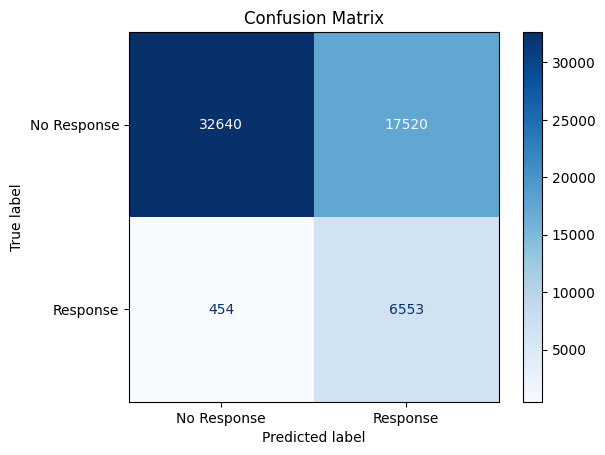

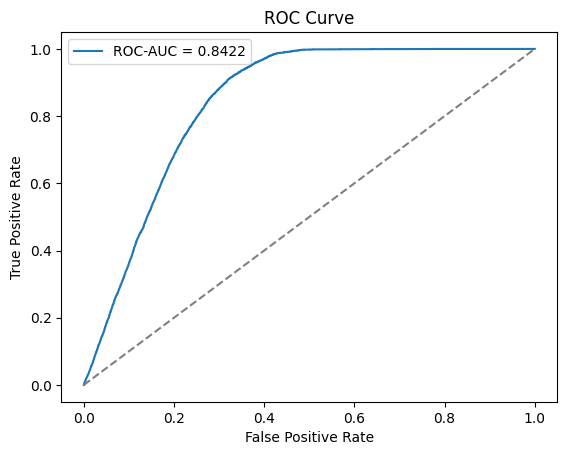

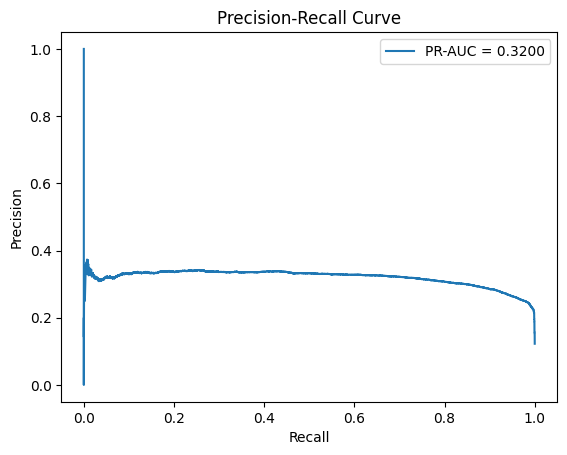

In [ ]:
# Using scaled data, no resampling
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=2)
metrics = train_and_evaluate_model(model, X_train_sc, y_train, X_val_sc, y_val)

In [ ]:
scores["Logistic Regression, no resampling"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.6840
Precision: 0.2713
Recall:    0.9363
F1 Score:  0.4207
ROC-AUC:   0.8423
PR-AUC:    0.3200


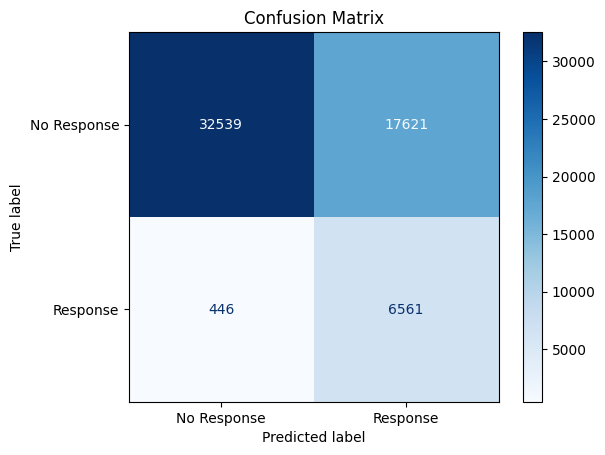

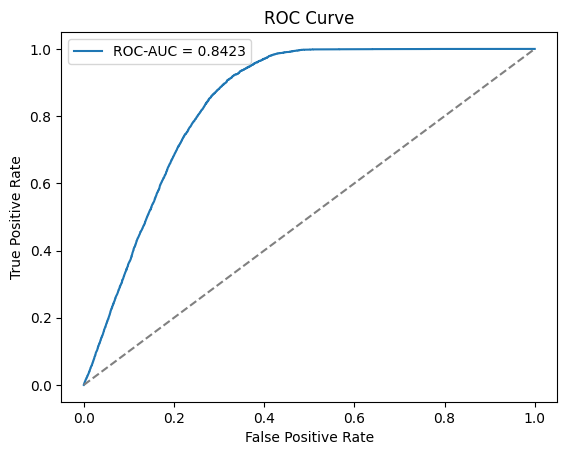

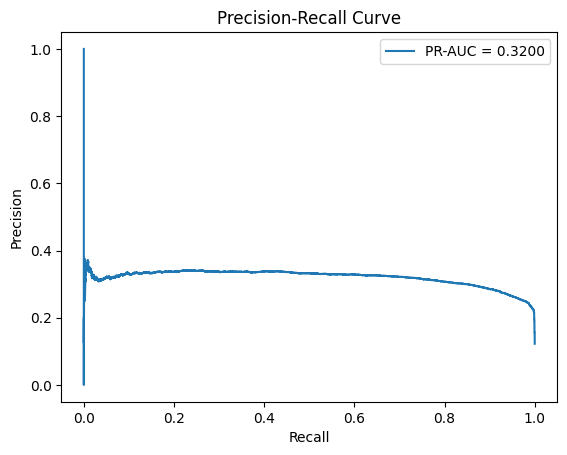

In [ ]:
# Using SMOTE data
model = LogisticRegression(max_iter=1000, random_state=2)
metrics = train_and_evaluate_model(model, X_train_smote, y_train_smote, X_val_sc, y_val)

In [ ]:
scores["Logistic Regression, SMOTE"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.8356
Precision: 0.3362
Recall:    0.3505
F1 Score:  0.3432
ROC-AUC:   0.8422
PR-AUC:    0.3205


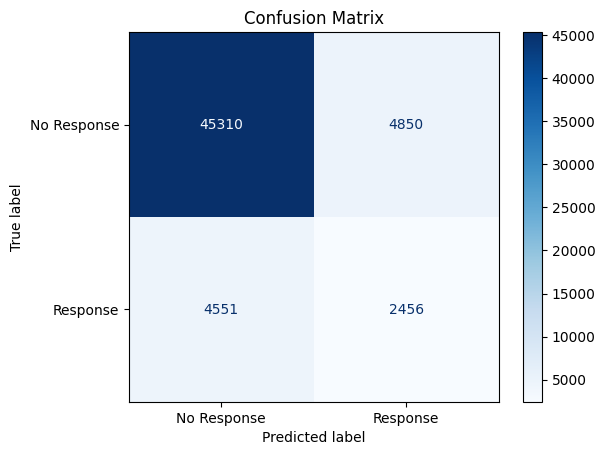

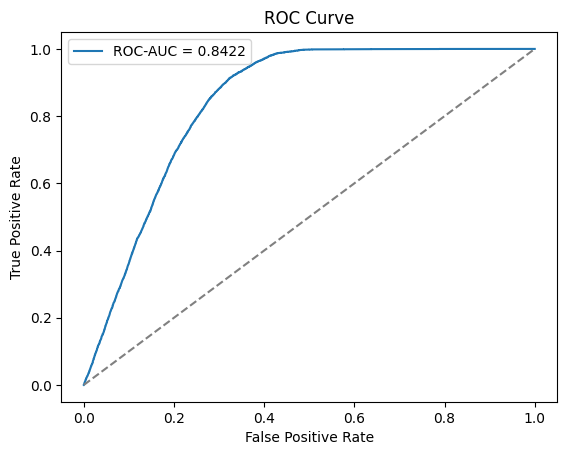

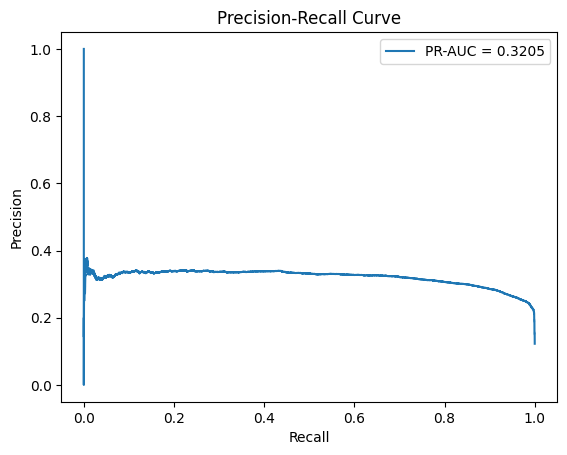

In [ ]:
# Using NCL data
model = LogisticRegression(max_iter=1000, random_state=2)
metrics = train_and_evaluate_model(model, X_train_ncl, y_train_ncl, X_val_sc, y_val)

In [ ]:
scores["Logistic Regression, NCL"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

## Random Forest

--- Metrics ---
Accuracy:  0.8715
Precision: 0.3988
Recall:    0.0959
F1 Score:  0.1546
ROC-AUC:   0.8376
PR-AUC:    0.3306


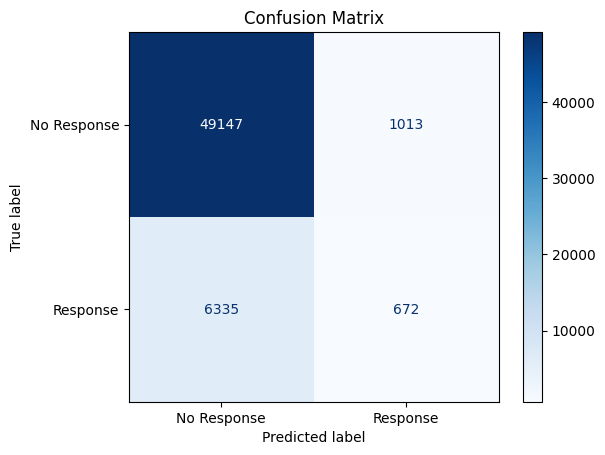

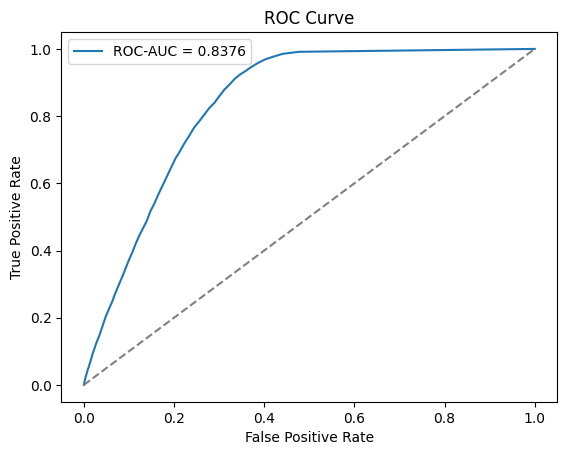

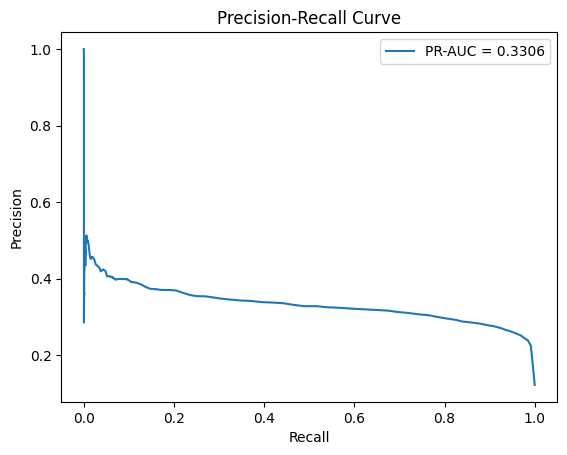

In [ ]:
# Data not resampled
model = RandomForestClassifier(class_weight='balanced', random_state=2)
metrics = train_and_evaluate_model(model, X_train_sc, y_train, X_val_sc, y_val)

In [ ]:
scores["Random Forest, no resampling"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.8344
Precision: 0.3406
Recall:    0.3748
F1 Score:  0.3569
ROC-AUC:   0.8353
PR-AUC:    0.3239


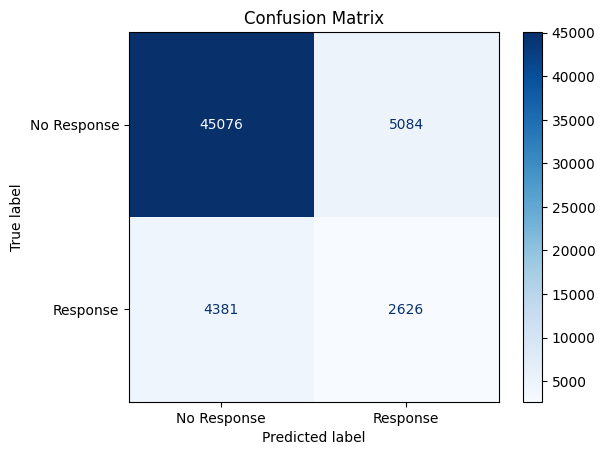

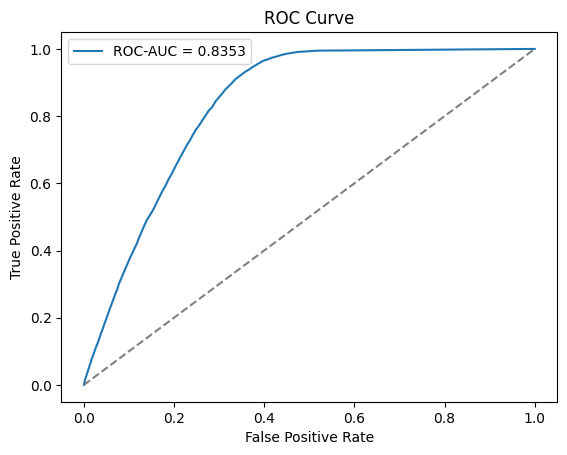

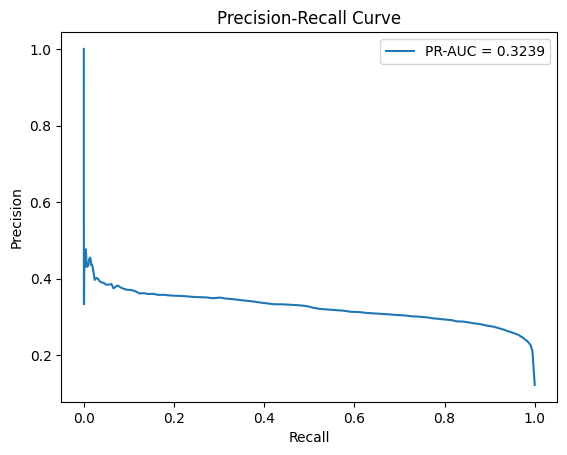

In [ ]:
# SMOTE data
model = RandomForestClassifier(random_state=2)
metrics = train_and_evaluate_model(model, X_train_smote, y_train_smote, X_val_sc, y_val)

In [ ]:
scores["Random Forest, SMOTE"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.8212
Precision: 0.3436
Recall:    0.5045
F1 Score:  0.4088
ROC-AUC:   0.8446
PR-AUC:    0.3399


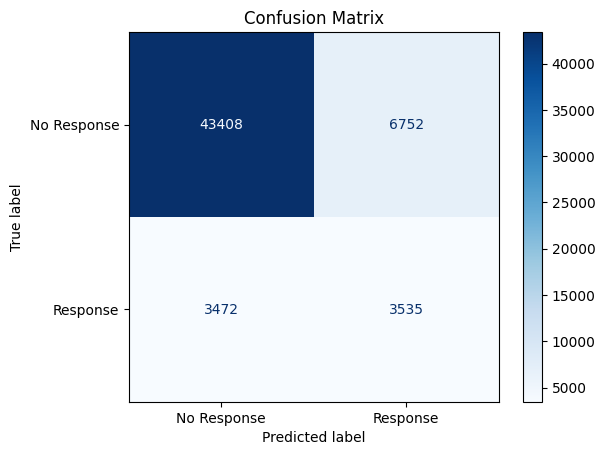

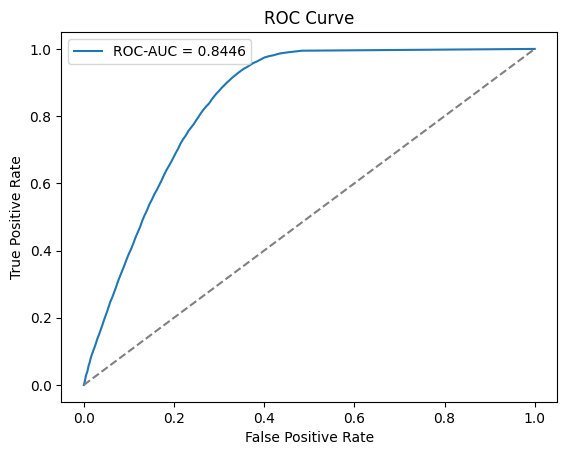

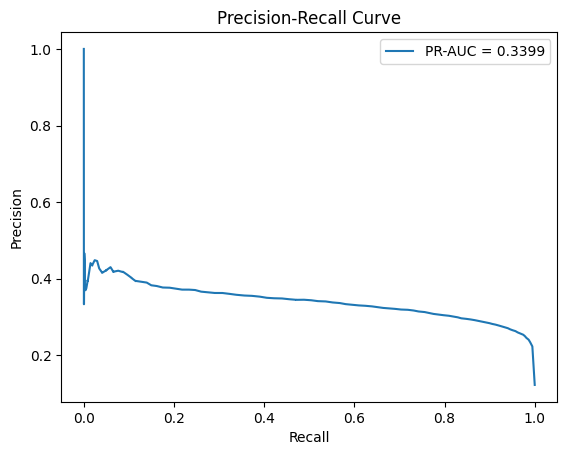

In [ ]:
# NCL data
model = RandomForestClassifier(random_state=2)
metrics = train_and_evaluate_model(model, X_train_ncl, y_train_ncl, X_val_sc, y_val)

In [ ]:
scores["Random Forest, NCL"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

## XGBoost

--- Metrics ---
Accuracy:  0.7169
Precision: 0.2895
Recall:    0.9005
F1 Score:  0.4381
ROC-AUC:   0.8540
PR-AUC:    0.3640


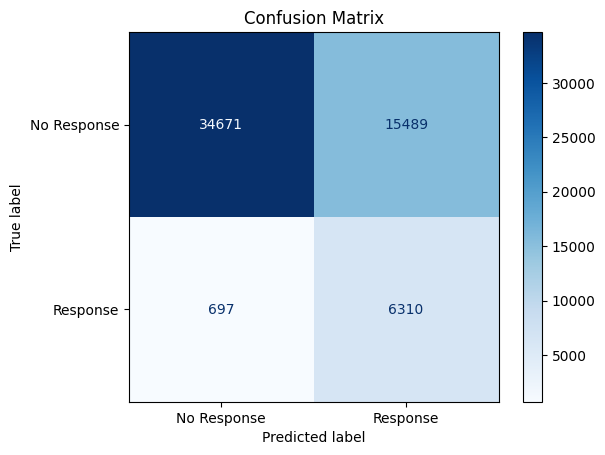

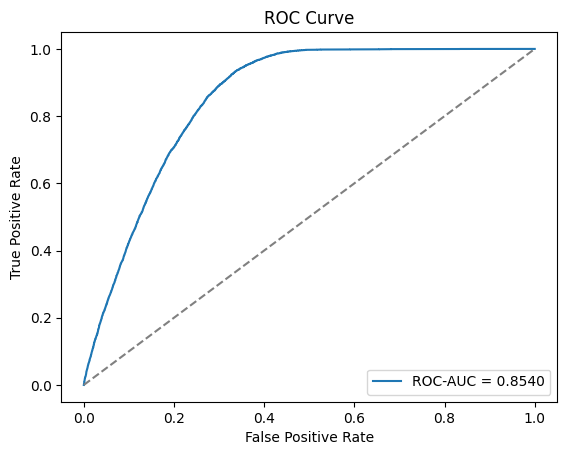

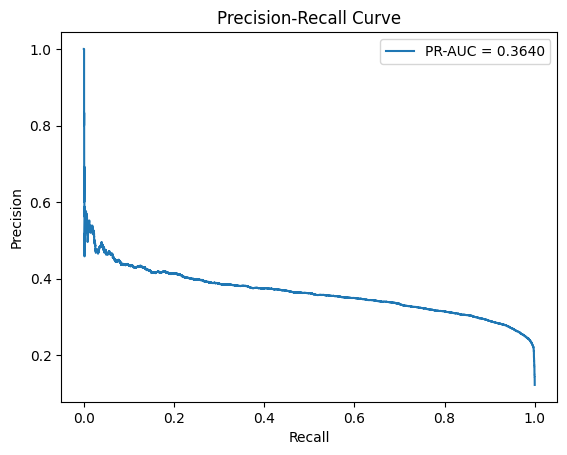

In [ ]:
# Data not resampled

neg, pos = y_train.value_counts()
weight_ratio = neg / pos

model = XGBClassifier(
    scale_pos_weight=weight_ratio,
    eval_metric='logloss',
    random_state=2
)
metrics = train_and_evaluate_model(model, X_train_sc, y_train, X_val_sc, y_val)

In [ ]:
scores["XGBoost, no resampling"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.8350
Precision: 0.3461
Recall:    0.3889
F1 Score:  0.3663
ROC-AUC:   0.8444
PR-AUC:    0.3339


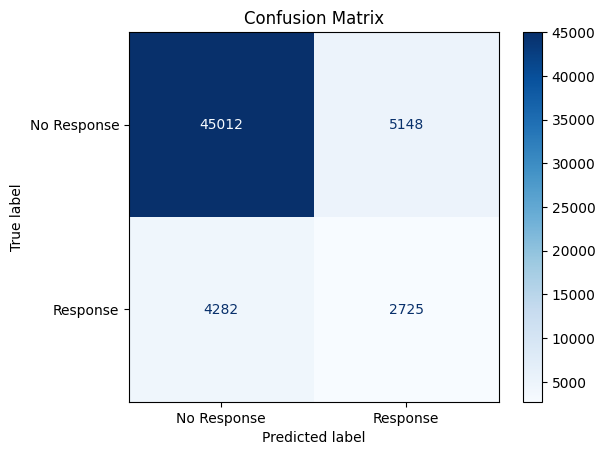

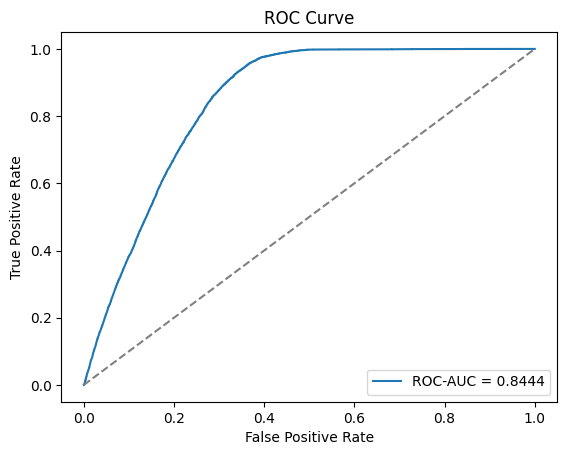

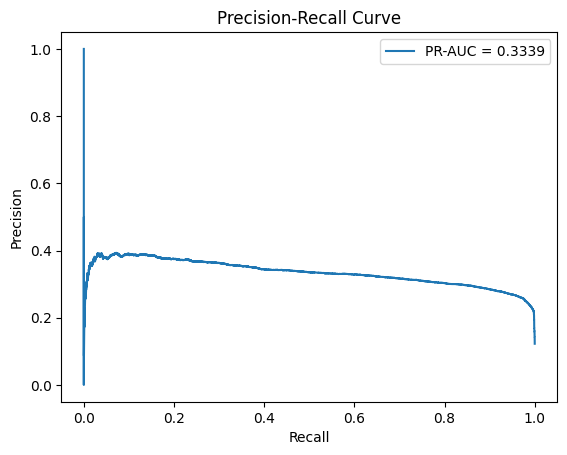

In [ ]:
# SMOTE
model = XGBClassifier(eval_metric='logloss', random_state=2)
metrics = train_and_evaluate_model(model, X_train_smote, y_train_smote, X_val_sc, y_val)

In [ ]:
scores["XGBoost, SMOTE"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

--- Metrics ---
Accuracy:  0.8273
Precision: 0.3577
Recall:    0.5143
F1 Score:  0.4219
ROC-AUC:   0.8542
PR-AUC:    0.3632


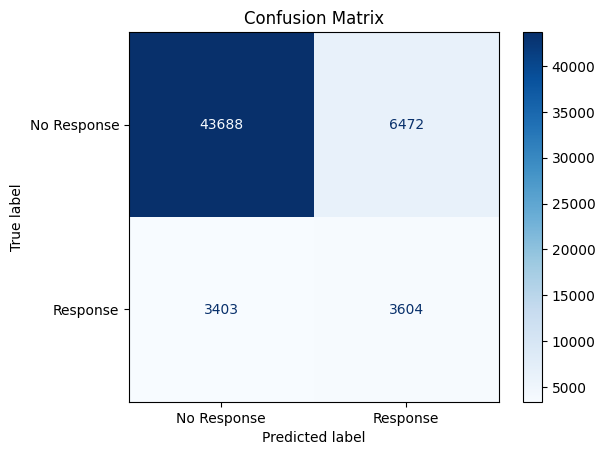

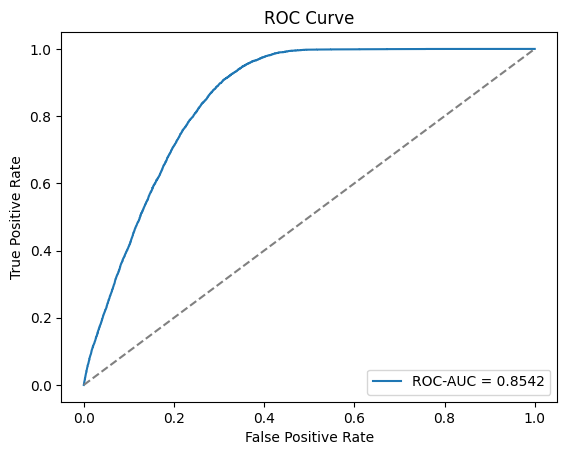

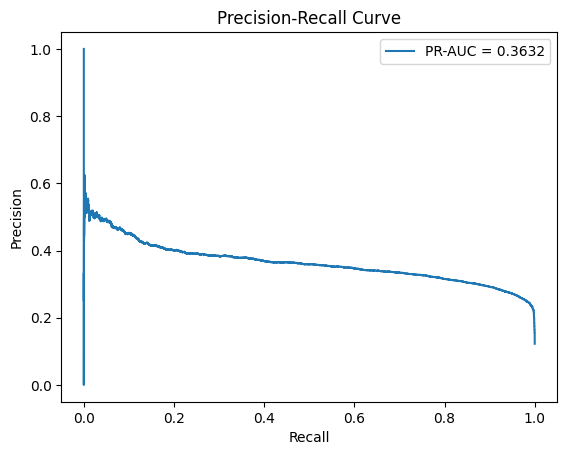

In [ ]:
# NCL
model = XGBClassifier(eval_metric='logloss', random_state=2)
metrics = train_and_evaluate_model(model, X_train_ncl, y_train_ncl, X_val_sc, y_val)

In [ ]:
scores["XGBoost, NCL"] = {
    "F1":metrics['f1'],
    "PR-AUC":metrics['pr_auc']
}

In [ ]:
scores_df = pd.DataFrame.from_dict(scores, orient='index')
scores_df

,F1,PR-AUC
"Logistic Regression, no resampling",0.421686,0.319972
"Logistic Regression, SMOTE",0.420725,0.320004
"Logistic Regression, NCL",0.343185,0.320486
"Random Forest, no resampling",0.154625,0.330611
"Random Forest, SMOTE",0.356866,0.323912
"Random Forest, NCL",0.408812,0.339869
"XGBoost, no resampling",0.438103,0.363957
"XGBoost, SMOTE",0.366263,0.333927
"XGBoost, NCL",0.421940,0.363172


The best performing model was XGBoost with no resampling, so we will move forward with this model

#Tuning Model

##Tune hyperparameters

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

base_model = XGBClassifier(
    scale_pos_weight=weight_ratio,
    eval_metric='logloss',
    random_state=2
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sc, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
Best CV PR-AUC: 0.3711276528762351


In [ ]:
best_model = grid_search.best_estimator_

## Threshold tuning

In [ ]:
y_proba_val = best_model.predict_proba(X_val_sc)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_val >= t).astype(int)
    threshold_results.append({
        'threshold': t,
        'precision': precision_score(y_val, y_pred_t),
        'recall': recall_score(y_val, y_pred_t),
        'f1': f1_score(y_val, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,threshold,precision,recall,f1
0,0.05,0.224040,0.996718,0.365846
1,0.10,0.231014,0.994577,0.374939
2,0.15,0.238604,0.991294,0.384628
3,0.20,0.245238,0.986585,0.392829
4,0.25,0.251419,0.979877,0.400163
5,0.30,0.255907,0.975310,0.405434
6,0.35,0.261678,0.969745,0.412143
7,0.40,0.268865,0.959041,0.419987
8,0.45,0.275622,0.943771,0.426645
9,0.50,0.282754,0.928928,0.433543


In [ ]:
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
print(f"Best threshold: {best_threshold:.2f}")

y_pred_val = (y_proba_val >= best_threshold).astype(int)
print(f"F1 at best threshold: {f1_score(y_val, y_pred_val):.4f}")

Best threshold: 0.65
F1 at best threshold: 0.4583


# Evaluate final model

## Feature Engineering and Scaling

In [ ]:
X_full_train_fresh, X_test_fresh, y_full_train_fresh, y_test_fresh = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=2
)

In [ ]:
region_response_rates_final, global_rate_final = smoothed_target_encode(
    X_full_train['Region_Code'], y_full_train, smoothing=20
)
channel_response_rates_final, _ = smoothed_target_encode(
    X_full_train['Policy_Sales_Channel'], y_full_train, smoothing=20
)

X_full_train['Region_Response_Rate'] = X_full_train['Region_Code'].map(region_response_rates_final)
X_full_train['Channel_Response_Rate'] = X_full_train['Policy_Sales_Channel'].map(channel_response_rates_final)

X_test['Region_Response_Rate'] = X_test_fresh['Region_Code'].map(region_response_rates_final)
X_test['Channel_Response_Rate'] = X_test_fresh['Policy_Sales_Channel'].map(channel_response_rates_final)

X_test['Region_Response_Rate'] = X_test['Region_Response_Rate'].fillna(global_rate)
X_test['Channel_Response_Rate'] = X_test['Channel_Response_Rate'].fillna(global_rate)

In [ ]:
del X_full_train['Annual_Premium']
del X_full_train['Region_Code']
del X_full_train['Policy_Sales_Channel']

In [ ]:
scaler = StandardScaler()
X_full_train_sc = scaler.fit_transform(X_full_train)
X_test_sc = scaler.transform(X_test)

## Train final model

In [ ]:
neg, pos = y_full_train.value_counts()
weight_ratio_final = neg/pos

final_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.01,
    max_depth=7,
    n_estimators=500,
    subsample=1.0,
    scale_pos_weight=weight_ratio_final,
    eval_metric='logloss',
    random_state=2
)
final_model.fit(X_full_train_sc, y_full_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_proba_test = final_model.predict_proba(X_test_sc)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

## Results

--- Metrics ---
Accuracy:  0.7631
Precision: 0.3171
Recall:    0.8082
F1 Score:  0.4554
ROC-AUC:   0.8574
PR-AUC:    0.3750


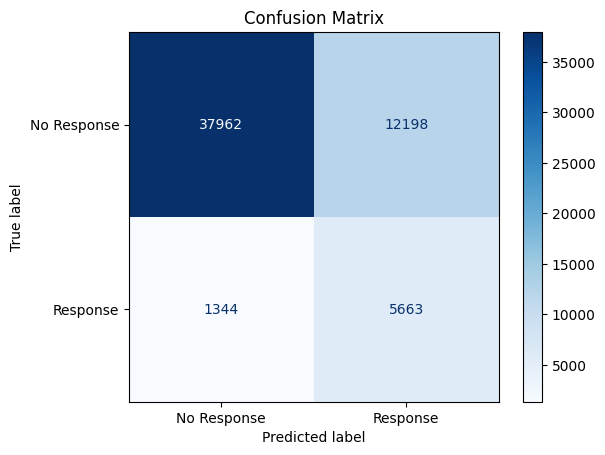

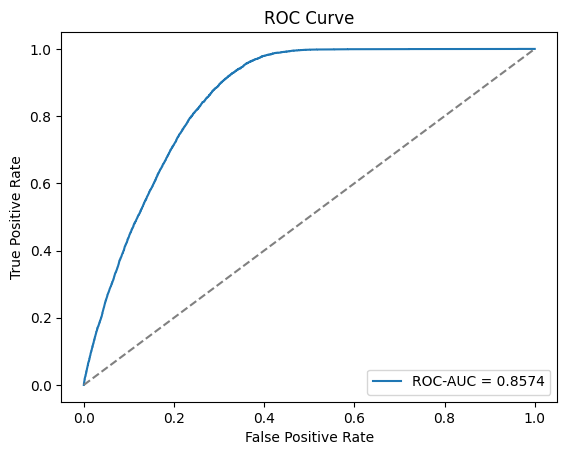

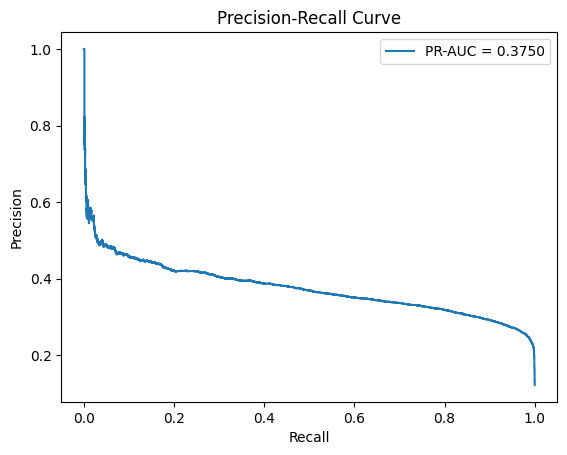

In [ ]:
# Metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)

print(f"--- Metrics ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"PR-AUC:    {pr_auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Response', 'Response'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC-AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve')
plt.legend()
plt.show()

# Precision-Recall curve
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_test)
plt.figure()
plt.plot(recalls, precisions, label=f'PR-AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve')
plt.legend()
plt.show()